/home/wu12recu/Documents/pyFDN.worktrees/10-integrate-flare-and-flamo/.venv/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Correlation (FLAMO vs MATLAB): 0.999904


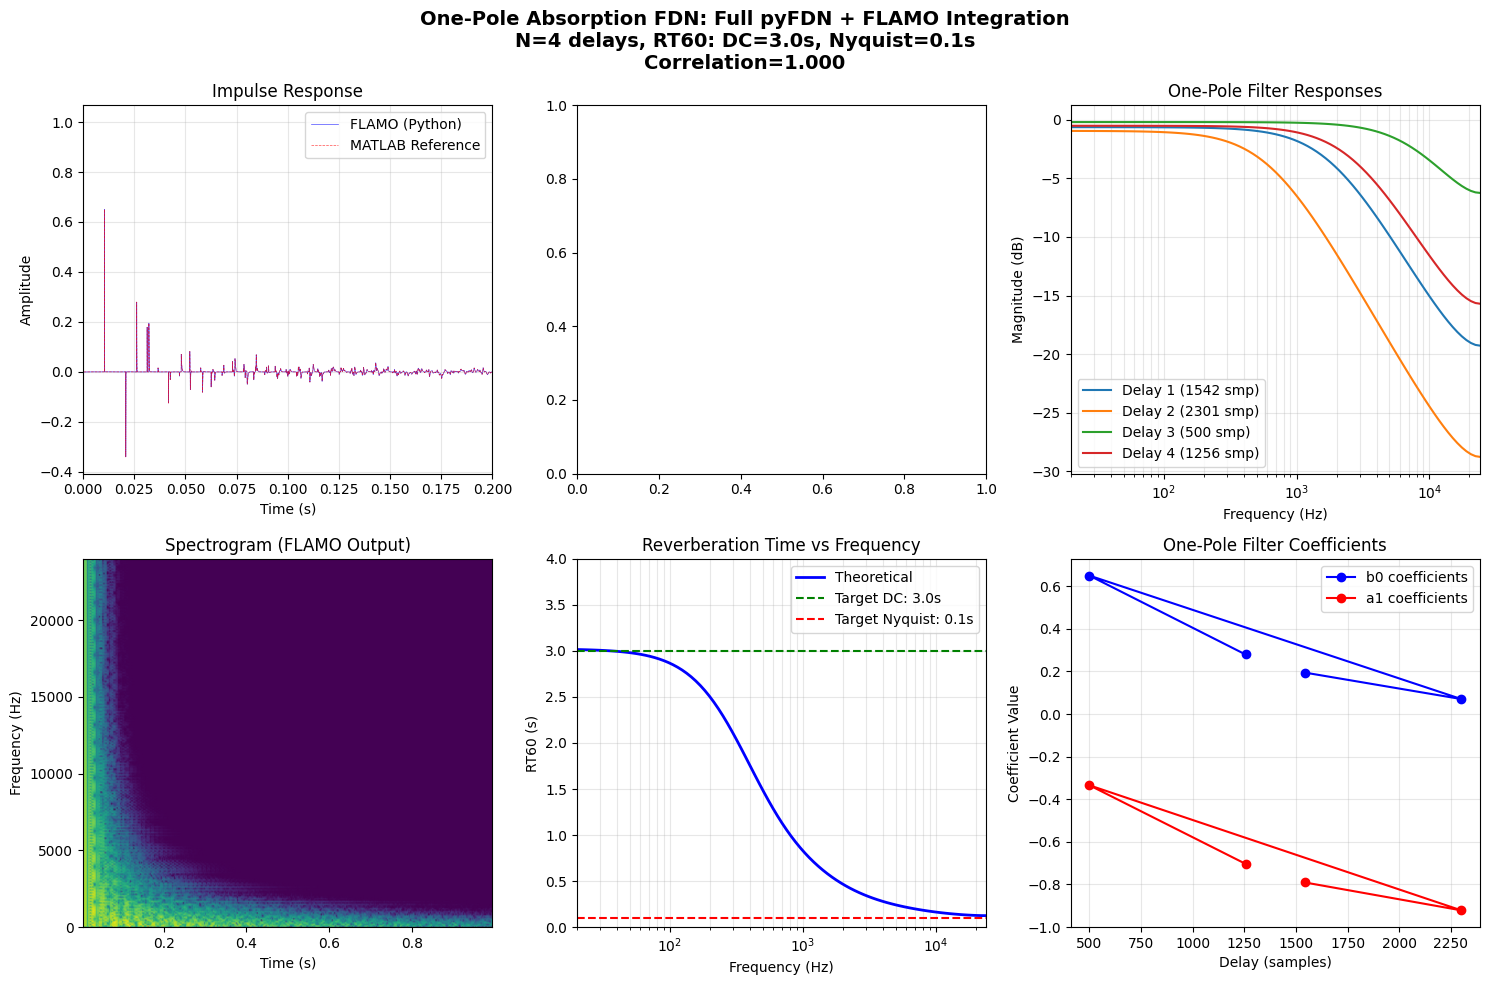

In [1]:
"""
Example: One-Pole Absorption FDN using FLAMO Integration

This example demonstrates the integration of FLAMO with existing pyFDN functions,
using one-pole absorption filters for frequency-dependent reverberation time. 
It integrates FLAMO's DSP framework with pyFDN's auxiliary functions

Based on:
- Jot & Chaigne (1991): Digital delay networks for designing artificial reverberators
- Original MATLAB code by Sebastian J. Schlecht, April 2018

Python implementation by Facundo Franchino, September 2025
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import OrderedDict
from pathlib import Path

from scipy.io import loadmat

# FLAMO imports for DSP components
from flamo.processor import dsp, system

# pyFDN imports for existing functionality
import sys
import os
# sys.path.append(os.path.join(os.path.dirname(__file__), '..'))

from pyFDN.auxiliary.one_pole_absorption import (
    one_pole_absorption,
    RT602slope,
    db2mag,
)


# random seed for reproducibility that matches MATLAB's implementation
np.random.seed(1)
torch.manual_seed(1)

# Load MATLAB regression reference
# __file__ is not defined in notebooks, so use the location of this notebook via cwd or %pwd trick
REFERENCE_MAT_FILE = Path().resolve().parent.parent.parent / "tests" / "reference" / "example_onePoleAbsorption.mat"
ref = loadmat(REFERENCE_MAT_FILE, simplify_cells=True)

# Extract reference parameters
RT_DC = float(ref["RT_DC"])
RT_NY = float(ref["RT_NY"])
delays = np.asarray(ref["delays"]).flatten()
fs = int(ref["fs"])
feedback_matrix = np.asarray(ref["feedbackMatrix"])
ir_matlab = np.asarray(ref["irTimeDomain"]).flatten()
N = int(ref["N"])

# Generate one-pole absorption coefficients using pyFDN (SOS format: shape (6, N))
sos = one_pole_absorption(RT_DC, RT_NY, delays, fs)

# Extract b0 and a1 for visualization
b0 = sos[0, :]  # b0 coefficients
a1 = sos[4, :]  # a1 coefficients

## Build FDN using FLAMO components

# FLAMO processing configuration
device = "cpu"
nfft = 2 ** 16
num_input = 1
num_output = 1
impulse_response_length = fs  # 1 second

# Convert to torch tensors
delays_torch = torch.tensor(delays, dtype=torch.float32)
feedback_matrix_torch = torch.tensor(feedback_matrix, dtype=torch.float32)
absorption_coeff = torch.tensor(sos[np.newaxis, ...], dtype=torch.float32)

# Input/Output Gains
input_gain = dsp.Gain(size=(N, num_input), nfft=nfft, device=device)
input_gain.assign_value(torch.ones(N, num_input))

output_gain = dsp.Gain(size=(num_output, N), nfft=nfft, device=device)
output_gain.assign_value(torch.ones(num_output, N))

# Delay Lines
delay_module = dsp.parallelDelay(
    size=(N,),
    max_len=int(delays_torch.max()),
    nfft=nfft,
    isint=True,
    unit=1,
    device=device,
)
delay_module.assign_value(delay_module.sample2s(delays_torch))

# Feedback Matrix
mixing_matrix = dsp.Matrix(
    size=(N, N),
    nfft=nfft,
    matrix_type="random",
    device=device,
)
mixing_matrix.assign_value(feedback_matrix_torch)

# Absorption Filters (SOS implementation)
absorption = dsp.parallelSOSFilter(
    size=(N,),
    n_sections=1,
    nfft=nfft,
    device=device,
)
absorption.assign_value(absorption_coeff)

# Delay + absorption branch
attenuated_delay = system.Series(
    OrderedDict(
        {
            "delay": delay_module,
            "absorption": absorption,
        }
    )
)

# Feedback loop
feedback_loop = system.Recursion(fF=attenuated_delay, fB=mixing_matrix)

# Assemble complete FDN
fdn = system.Series(
    OrderedDict(
        {
            "input_gain": input_gain,
            "feedback_loop": feedback_loop,
            "output_gain": output_gain,
        }
    )
)

# Add direct path branch
direct_gain = dsp.Gain(size=(num_output, num_input), nfft=nfft, device=device)
direct_gain.assign_value(torch.ones(num_output, num_input))

# Combine direct and FDN branches
complete_system = system.Parallel(
    brA=direct_gain,
    brB=fdn,
    sum_output=True,
)

# Create shell with FFT/iFFT processing
model = system.Shell(
    core=complete_system,
    input_layer=dsp.FFT(nfft),
    output_layer=dsp.iFFT(nfft),
)

## Generate and Analyse IR
ir_python = model.get_time_response().flatten()

# Trim to desired length
ir_python = ir_python[:impulse_response_length]

# Align MATLAB reference length
ir_matlab = ir_matlab[:impulse_response_length]

# Diagnostic metrics
min_len = min(len(ir_python), len(ir_matlab))
ir_python_trim = ir_python[:min_len]
ir_matlab_trim = ir_matlab[:min_len]
correlation = np.corrcoef(ir_python_trim, ir_matlab_trim)[0, 1]

print(f"Correlation (FLAMO vs MATLAB): {correlation:.6f}")

## Visualisation
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Time axis
t = np.arange(len(ir_python)) / fs

# Impulse Response
axes[0, 0].plot(
    t,
    ir_python,
    "b-",
    alpha=0.7,
    linewidth=0.5,
    label="FLAMO (Python)",
)
axes[0, 0].plot(
    t,
    ir_matlab,
    "r--",
    alpha=0.7,
    linewidth=0.5,
    label="MATLAB Reference",
)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_xlim([0, 0.2])
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].set_title('Impulse Response')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# # Energy Decay Curve
# edc_flamo = np.flip(np.cumsum(np.flip(ir_python_trim ** 2)))
# edc_flamo_db = 10 * np.log10(edc_flamo / (edc_flamo[0] + 1e-12))

# edc_matlab = np.flip(np.cumsum(np.flip(ir_matlab_trim ** 2)))
# edc_matlab_db = 10 * np.log10(edc_matlab / (edc_matlab[0] + 1e-12))

# axes[0, 1].plot(
#     t,
#     edc_flamo_db,
#     "b-",
#     alpha=0.8,
#     label="FLAMO",
# )
# axes[0, 1].plot(
#     t,
#     edc_matlab_db,
#     "r--",
#     alpha=0.8,
#     label="MATLAB",
# )
# axes[0, 1].set_xlabel('Time (s)')
# axes[0, 1].set_ylabel('Energy (dB)')
# axes[0, 1].set_title('Energy Decay Curves')
# axes[0, 1].legend()
# axes[0, 1].grid(True, alpha=0.3)
# axes[0, 1].set_ylim([-60, 0])

# Filter Frequency Response
freqs = np.logspace(1, np.log10(fs/2), 100)
omega = 2 * np.pi * freqs / fs

# One-pole filter response for each delay line
axes[0, 2].set_title('One-Pole Filter Responses')
for i in range(N):
    # H(z) = b0 / (1 + a1*z^-1)
    # H(e^jw) = b0 / (1 + a1*e^-jw)
    H = sos[0, i] / (1 + sos[4, i] * np.exp(-1j * omega))
    axes[0, 2].semilogx(freqs, 20 * np.log10(np.abs(H)), 
                        label=f'Delay {i+1} ({delays[i]} smp)')

axes[0, 2].set_xlabel('Frequency (Hz)')
axes[0, 2].set_ylabel('Magnitude (dB)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3, which='both')
axes[0, 2].set_xlim([20, fs/2])

# spectrogram
from scipy import signal
f_spec, t_spec, Sxx = signal.spectrogram(ir_python, fs, nperseg=512, noverlap=384)
axes[1, 0].pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-12),
                      shading='gouraud', cmap='viridis')
axes[1, 0].set_ylabel('Frequency (Hz)')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_title('Spectrogram (FLAMO Output)')
axes[1, 0].set_ylim([0, fs/2])

# RT60 vs Frequency (Theoretical)
axes[1, 1].set_title('Reverberation Time vs Frequency')

# Theoretical RT60 curve
RT60_theory = np.zeros_like(freqs)
for i, f in enumerate(freqs):
    omega_f = 2 * np.pi * f / fs
    # Average response across all filters
    H_avg = 0
    for j in range(N):
        H_f = np.abs(sos[0, j] / (1 + sos[4, j] * np.exp(-1j * omega_f)))
        H_avg += H_f
    H_avg /= N
    
    # Convert to RT60
    if H_avg > 0:
        slope = 20 * np.log10(H_avg) / np.mean(delays) * fs
        RT60_theory[i] = -60 / slope if slope < 0 else 10

axes[1, 1].semilogx(freqs, RT60_theory, 'b-', linewidth=2, label='Theoretical')
axes[1, 1].axhline(y=RT_DC, color='g', linestyle='--', label=f'Target DC: {RT_DC}s')
axes[1, 1].axhline(y=RT_NY, color='r', linestyle='--', label=f'Target Nyquist: {RT_NY}s')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('RT60 (s)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, which='both')
axes[1, 1].set_xlim([20, fs/2])
axes[1, 1].set_ylim([0, max(RT_DC * 1.2, 4)])

# filter coefficient visualisation 
axes[1, 2].plot(delays, sos[0, :], 'bo-', label='b0 coefficients')
axes[1, 2].plot(delays, sos[4, :], 'ro-', label='a1 coefficients')
axes[1, 2].set_xlabel('Delay (samples)')
axes[1, 2].set_ylabel('Coefficient Value')
axes[1, 2].set_title('One-Pole Filter Coefficients')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle(f'One-Pole Absorption FDN: Full pyFDN + FLAMO Integration\n'
             f'N={N} delays, RT60: DC={RT_DC}s, Nyquist={RT_NY}s\n'
             f'Correlation={correlation:.3f}',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Summary

# Note: The dss2pr function still needs to be translated once the modal decomposition 
# functionality is integrated into pyFDN for complete compatibility with fdnToolbox.

